In [1]:
# =============================================================================
# 🎙️ 音频深度伪造检测模型训练 - CNN-BiLSTM + ASVspoof 2019 LA
# =============================================================================
# 完全复用原项目 deepvoice_detection/train_deepvoice.py 的模型架构
# 核心改动:
#   1. 数据加载: 原项目 real_audio_dir/deepfake_audio_dir 两个平级目录
#      → 改为解析 ASVspoof 2019 LA 的 protocol 文件 + flac 目录
#   2. 模型/特征/训练逻辑: 100% 原样复用, 零改动
# =============================================================================

# ===================== Cell 1: 环境安装 =====================
# !pip install librosa soundfile scikit-learn tqdm matplotlib seaborn -q

In [2]:
# ===================== Cell 2: 导入库 =====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
import librosa
import numpy as np
import os
import csv
import json
import random
import warnings
import logging
from pathlib import Path
from datetime import datetime
from collections import Counter
from typing import List, Tuple, Dict, Optional

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from tqdm import tqdm

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s")
logger = logging.getLogger(__name__)

# ===================== Cell 3: 全局配置 =====================
# ──────────── 你需要修改的唯一部分: Kaggle 数据路径 ────────────
# ASVspoof 2019 数据集在 Kaggle 上的根目录
# 在 Kaggle 中添加数据集后, 确认路径是否正确
ASVSPOOF_ROOT = "/kaggle/input/asvpoof-2019-dataset"  # ← 根据你的Kaggle数据集名称调整
LA_ROOT = "/kaggle/input/asvpoof-2019-dataset/LA"
CONFIG = {
    # ────── ASVspoof 2019 LA 数据路径 ──────
    "asvspoof_root": ASVSPOOF_ROOT,
    "la_root": os.path.join(ASVSPOOF_ROOT, "LA"),
    
    # Protocol 文件 (标注真伪标签)
    "train_protocol": os.path.join(LA_ROOT, "LA", "ASVspoof2019_LA_cm_protocols",
                                   "ASVspoof2019.LA.cm.train.trn.txt"),
    "dev_protocol": os.path.join(LA_ROOT, "LA", "ASVspoof2019_LA_cm_protocols",
                                 "ASVspoof2019.LA.cm.dev.trl.txt"),
    
    # 音频文件目录
    "train_flac_dir": os.path.join(LA_ROOT, "LA", "ASVspoof2019_LA_train", "flac"),
    "dev_flac_dir": os.path.join(LA_ROOT, "LA", "ASVspoof2019_LA_dev", "flac"),
    
    # ────── 特征参数 (与原项目 deepvoice_config.json 一致) ──────
    "feature_params": {
        "n_mfcc": 13,
        "n_fft": 2048,
        "hop_length": 512,
        "max_length": 500,   # 约 16 秒 @ 16kHz, hop=512
    },
    
    # ────── 模型参数 (与原项目完全一致) ──────
    "model_params": {
        "num_classes": 2,        # 0=bonafide, 1=spoof
        "conv_in_channels": 13,  # 必须 == n_mfcc
        "conv_out_channels": 32,
        "lstm_hidden_size": 64,
        "fc1_out_features": 128,
    },
    
    # ────── 训练参数 (基于原项目, 适当调优) ──────
    "training_params": {
        "num_epochs": 6,
        "batch_size": 32,
        "learning_rate": 1e-4,
        "num_workers": 4,
        "validation_split": 0.0,
        "random_seed": 42,
        "lr_scheduler_patience": 2,
        "lr_scheduler_factor": 0.5,
        "early_stopping_patience": 3,
    },
    
    # ────── 输出路径 ──────
    "output_paths": {
        "log_csv_path": "/kaggle/working/train_deepfake_metrics_log.csv",
        "model_save_path": "/kaggle/working/model/last_epoch_model.pt",
        "best_model_save_path": "/kaggle/working/model/best_f1_model.pt",
    },
    
    "seed": 42,
}

def set_seed(seed_value=42):
    """与原项目 set_seed() 完全一致"""
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")
if torch.cuda.is_available():
    logger.info(f"GPU: {torch.cuda.get_device_name(0)}")

os.makedirs(os.path.dirname(CONFIG["output_paths"]["best_model_save_path"]), exist_ok=True)

2026-02-13 08:01:34,014 - INFO - Using device: cuda
2026-02-13 08:01:34,055 - INFO - GPU: Tesla T4


In [3]:
# # ===================== Cell 4: 数据集探索 =====================
# print("=" * 70)
# print("📂 Step 1: 探索 ASVspoof 2019 LA 数据集结构")
# print("=" * 70)

# la_root = Path(CONFIG["la_root"])
# print(f"\nLA 根目录: {la_root}")
# print(f"目录是否存在: {la_root.exists()}")

# if la_root.exists():
#     print(f"\nLA 目录结构:")
#     for item in sorted(la_root.iterdir()):
#         if item.is_dir():
#             # 计算目录下文件数
#             file_count = sum(1 for f in item.rglob("*") if f.is_file())
#             print(f"  📁 {item.name}/ ({file_count} files)")
#         else:
#             size_kb = item.stat().st_size / 1024
#             print(f"  📄 {item.name} ({size_kb:.1f} KB)")

# # 检查关键文件
# for key, path in [("train_protocol", CONFIG["train_protocol"]),
#                    ("dev_protocol", CONFIG["dev_protocol"]),
#                    ("train_flac_dir", CONFIG["train_flac_dir"]),
#                    ("dev_flac_dir", CONFIG["dev_flac_dir"])]:
#     exists = os.path.exists(path)
#     print(f"\n  {'✅' if exists else '❌'} {key}: {path}")
#     if exists and os.path.isdir(path):
#         files = os.listdir(path)
#         print(f"     文件数: {len(files)}, 示例: {files[:3]}")

In [4]:
# ===================== Cell 5: ASVspoof 2019 Protocol 解析器 =====================
print("\n" + "=" * 70)
print("📊 Step 2: 解析 ASVspoof 2019 LA Protocol 文件")
print("=" * 70)

class ASVspoofDataLoader:
    """
    ASVspoof 2019 LA 数据集解析器
    
    适配原项目 train_deepvoice.py 的数据加载逻辑:
    原项目: real_audio_dir → label=0, deepfake_audio_dir → label=1
    本解析器: protocol 文件中 bonafide → label=0, spoof → label=1
    
    Protocol 文件格式 (每行, 空格分隔):
    LA_0079 LA_T_1138215 - A01 spoof
    LA_0079 LA_T_1138220 - - bonafide
    
    列含义:
    [0] SPEAKER_ID   - 说话人ID
    [1] AUDIO_NAME   - 音频文件名 (不含扩展名)
    [2] -            - 占位符
    [3] ATTACK_ID    - 攻击算法 (A01-A19) 或 "-" (bonafide)
    [4] LABEL        - "bonafide" 或 "spoof"
    """
    
    def __init__(self, config: dict):
        self.config = config
    
    def parse_protocol(self, protocol_path: str, flac_dir: str) -> Tuple[List[str], List[int], List[dict]]:
        """
        解析单个 protocol 文件
        
        Returns:
            file_paths: 音频文件完整路径列表
            labels: 标签列表 (0=bonafide, 1=spoof)
            metadata: 元数据列表 (speaker_id, attack_id 等)
        """
        file_paths = []
        labels = []
        metadata = []
        
        skipped = 0
        
        with open(protocol_path, "r") as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5:
                    skipped += 1
                    continue
                
                speaker_id = parts[0]
                audio_name = parts[1]
                attack_id = parts[3]
                label_str = parts[4]
                
                # 构建完整音频路径
                audio_path = os.path.join(flac_dir, f"{audio_name}.flac")
                
                # 检查文件是否存在
                if not os.path.exists(audio_path):
                    skipped += 1
                    continue
                
                # 标签: bonafide=0 (real), spoof=1 (deepfake)
                # 与原项目 train_deepvoice.py 一致: 0=real, 1=deepfake
                if label_str == "bonafide":
                    label = 0
                elif label_str == "spoof":
                    label = 1
                else:
                    skipped += 1
                    continue
                
                file_paths.append(audio_path)
                labels.append(label)
                metadata.append({
                    "speaker_id": speaker_id,
                    "audio_name": audio_name,
                    "attack_id": attack_id,
                    "label_str": label_str,
                })
        
        if skipped > 0:
            logger.info(f"  跳过 {skipped} 条记录 (文件不存在或格式异常)")
        
        return file_paths, labels, metadata
    
    def load_train_dev(self) -> Dict:
        """
        加载训练集和开发集
        
        Returns:
            dict: 包含 train_files, train_labels, dev_files, dev_labels 等
        """
        result = {}
        
        # ── 训练集 ──
        print(f"\n  解析训练集 protocol: {self.config['train_protocol']}")
        train_files, train_labels, train_meta = self.parse_protocol(
            self.config["train_protocol"], self.config["train_flac_dir"]
        )
        result["train_files"] = train_files
        result["train_labels"] = train_labels
        result["train_meta"] = train_meta
        
        train_counts = Counter(train_labels)
        print(f"  ✅ 训练集: {len(train_files)} 样本 "
              f"(bonafide={train_counts.get(0,0)}, spoof={train_counts.get(1,0)})")
        
        # ── 开发/验证集 ──
        print(f"\n  解析开发集 protocol: {self.config['dev_protocol']}")
        dev_files, dev_labels, dev_meta = self.parse_protocol(
            self.config["dev_protocol"], self.config["dev_flac_dir"]
        )
        result["dev_files"] = dev_files
        result["dev_labels"] = dev_labels
        result["dev_meta"] = dev_meta
        
        dev_counts = Counter(dev_labels)
        print(f"  ✅ 开发集: {len(dev_files)} 样本 "
              f"(bonafide={dev_counts.get(0,0)}, spoof={dev_counts.get(1,0)})")
        
        # ── 攻击类型分布 ──
        print(f"\n  ── 训练集攻击类型分布 ──")
        train_attacks = [m["attack_id"] for m, l in zip(train_meta, train_labels) if l == 1]
        for atk, cnt in sorted(Counter(train_attacks).items()):
            print(f"    {atk}: {cnt} 样本")
        
        return result

# 执行加载
asvspoof_loader = ASVspoofDataLoader(CONFIG)
data = asvspoof_loader.load_train_dev()


📊 Step 2: 解析 ASVspoof 2019 LA Protocol 文件

  解析训练集 protocol: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
  ✅ 训练集: 25380 样本 (bonafide=2580, spoof=22800)

  解析开发集 protocol: /kaggle/input/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
  ✅ 开发集: 24844 样本 (bonafide=2548, spoof=22296)

  ── 训练集攻击类型分布 ──
    A01: 3800 样本
    A02: 3800 样本
    A03: 3800 样本
    A04: 3800 样本
    A05: 3800 样本
    A06: 3800 样本



📈 Step 3: 数据统计与可视化


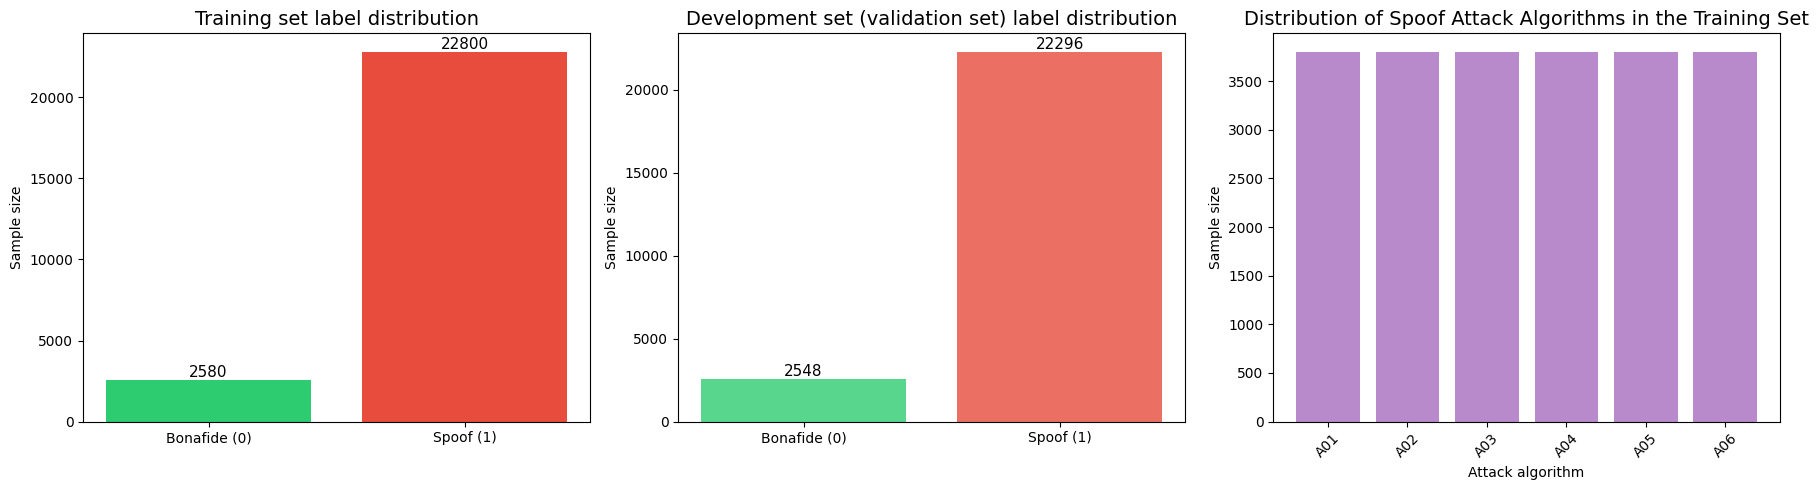


🎵 音频时长抽样统计 (随机抽取 200 个文件):
  采样率: 16000 Hz
  最短: 1.17s, 最长: 10.28s
  平均: 3.54s, 中位数: 3.33s


In [5]:
# ===================== Cell 6: 数据可视化 =====================
print("\n" + "=" * 70)
print("📈 Step 3: 数据统计与可视化")
print("=" * 70)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 训练集标签分布
train_counts = Counter(data["train_labels"])
ax1 = axes[0]
bars = ax1.bar(["Bonafide (0)", "Spoof (1)"],
               [train_counts.get(0, 0), train_counts.get(1, 0)],
               color=["#2ecc71", "#e74c3c"])
ax1.set_title("Training set label distribution", fontsize=14)
ax1.set_ylabel("Sample size")
for bar in bars:
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11)

# 开发集标签分布
dev_counts = Counter(data["dev_labels"])
ax2 = axes[1]
bars = ax2.bar(["Bonafide (0)", "Spoof (1)"],
               [dev_counts.get(0, 0), dev_counts.get(1, 0)],
               color=["#2ecc71", "#e74c3c"], alpha=0.8)
ax2.set_title("Development set (validation set) label distribution", fontsize=14)
ax2.set_ylabel("Sample size")
for bar in bars:
    ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
             f'{int(bar.get_height())}', ha='center', va='bottom', fontsize=11)

# 训练集攻击算法分布
ax3 = axes[2]
train_attacks = [m["attack_id"] for m, l in zip(data["train_meta"], data["train_labels"]) if l == 1]
atk_counts = Counter(train_attacks)
atk_sorted = sorted(atk_counts.items())
if atk_sorted:
    atk_names, atk_vals = zip(*atk_sorted)
    ax3.bar(atk_names, atk_vals, color="#9b59b6", alpha=0.7)
    ax3.set_title("Distribution of Spoof Attack Algorithms in the Training Set", fontsize=14)
    ax3.set_xlabel("Attack algorithm")
    ax3.set_ylabel("Sample size")
    ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("/kaggle/working/asvspoof_data_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# 音频时长抽样统计
print("\n🎵 音频时长抽样统计 (随机抽取 200 个文件):")
sample_files = random.sample(data["train_files"], min(200, len(data["train_files"])))
durations = []
for sf in sample_files:
    try:
        y, sr = librosa.load(sf, sr=None, duration=30)
        durations.append(len(y) / sr)
    except:
        pass
if durations:
    print(f"  采样率: {sr} Hz")
    print(f"  最短: {min(durations):.2f}s, 最长: {max(durations):.2f}s")
    print(f"  平均: {np.mean(durations):.2f}s, 中位数: {np.median(durations):.2f}s")

In [6]:
import os
import csv
import random
import numpy as np
from datetime import datetime
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import librosa
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, balanced_accuracy_score
)

# ===================== 0. 固定随机种子 =====================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ===================== 1. 模型定义 (原 AudioCNNLSTM) =====================
class AudioCNNLSTM(nn.Module):
    def __init__(self, model_config):
        super(AudioCNNLSTM, self).__init__()
        self.conv1 = nn.Conv1d(
            in_channels=model_config['conv_in_channels'],
            out_channels=model_config['conv_out_channels'],
            kernel_size=3,
            padding=1
        )
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=2)

        self.lstm = nn.LSTM(
            input_size=model_config['conv_out_channels'],
            hidden_size=model_config['lstm_hidden_size'],
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        self.fc1 = nn.Linear(model_config['lstm_hidden_size'] * 2, model_config['fc1_out_features'])
        self.fc2 = nn.Linear(model_config['fc1_out_features'], model_config['num_classes'])

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        x = x.permute(0, 2, 1)

        lstm_out, _ = self.lstm(x)
        x = lstm_out[:, -1, :]

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


# ===================== 2. MFCC 提取 (原 extract_mfcc_features) =====================
def extract_mfcc_features(audio_path, feature_config):
    n_mfcc = feature_config['n_mfcc']
    n_fft = feature_config['n_fft']
    hop_length = feature_config['hop_length']
    max_length = feature_config['max_length']

    try:
        audio_data, sr = librosa.load(audio_path, sr=None)
        mfccs = librosa.feature.mfcc(
            y=audio_data, sr=sr,
            n_mfcc=n_mfcc,
            n_fft=n_fft,
            hop_length=hop_length
        ).T

        if mfccs.shape[0] > max_length:
            mfccs = mfccs[:max_length, :]
        else:
            pad_width = max_length - mfccs.shape[0]
            mfccs = np.pad(mfccs, ((0, pad_width), (0, 0)), mode='constant')

        return mfccs
    except:
        return None


# ===================== 3. Dataset（带缓存，大幅加速） =====================
class AudioDataset(Dataset):
    def __init__(self, file_paths, labels, feature_config, cache_dir="/kaggle/working/mfcc_cache"):
        self.file_paths = file_paths
        self.labels = labels
        self.feature_config = feature_config
        self.cache_dir = cache_dir
        os.makedirs(self.cache_dir, exist_ok=True)

    def __len__(self):
        return len(self.file_paths)

    def _cache_path(self, audio_path):
        fname = os.path.basename(audio_path).replace(".flac", "").replace(".wav", "")
        return os.path.join(self.cache_dir, fname + ".npy")

    def __getitem__(self, idx):
        audio_path = self.file_paths[idx]
        label = self.labels[idx]

        cache_path = self._cache_path(audio_path)

        if os.path.exists(cache_path):
            try:
                mfccs = np.load(cache_path)
            except:
                mfccs = None
        else:
            mfccs = extract_mfcc_features(audio_path, self.feature_config)
            if mfccs is not None:
                np.save(cache_path, mfccs)

        if mfccs is None:
            return None

        return (
            torch.tensor(mfccs, dtype=torch.float32).transpose(0, 1),
            torch.tensor(label, dtype=torch.long)
        )


def collate_fn_skip_none(batch):
    batch = [b for b in batch if b is not None]
    if len(batch) == 0:
        return None
    return torch.utils.data.dataloader.default_collate(batch)


# ===================== 4. 评估函数 =====================
def compute_eer(y_true, y_score):
    """
    Equal Error Rate (EER)
    y_true: 0/1 标签（0=Bonafide, 1=Spoof）
    y_score: 正类(1=Spoof)的概率/分数（越大越像 Spoof）
    return: eer(float), eer_threshold(float)
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    # roc_curve 会返回 fpr, tpr, thresholds
    fpr, tpr, thresholds = roc_curve(y_true, y_score, pos_label=1)
    fnr = 1.0 - tpr

    # 找到 |FPR - FNR| 最小点作为 EER 近似
    idx = np.nanargmin(np.abs(fpr - fnr))
    eer = float((fpr[idx] + fnr[idx]) / 2.0)
    eer_thr = float(thresholds[idx])
    return eer, eer_thr
    
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0

    all_preds = []
    all_targets = []
    all_probs = []

    with torch.no_grad():
        for batch_data in dataloader:
            if batch_data is None:
                continue

            inputs, targets = batch_data
            inputs = inputs.to(device)
            targets = targets.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            all_probs.extend(probs.detach().cpu().numpy())
            all_preds.extend(preds.detach().cpu().numpy())
            all_targets.extend(targets.detach().cpu().numpy())

    if len(all_targets) == 0:
        return {
            "loss": 0,
            "accuracy": 0,
            "precision": 0,
            "recall": 0,
            "f1": 0,
            "balanced_acc": 0,
            "eer": 0,
            "eer_threshold": 0,
            "all_preds": [],
            "all_targets": [],
            "all_probs": []
        }

    avg_loss = total_loss / max(1, len(dataloader))

    acc = accuracy_score(all_targets, all_preds)
    prec = precision_score(all_targets, all_preds, zero_division=0)
    rec = recall_score(all_targets, all_preds, zero_division=0)
    f1 = f1_score(all_targets, all_preds, zero_division=0)
    bal_acc = balanced_accuracy_score(all_targets, all_preds)
    eer, eer_thr = compute_eer(all_targets, all_probs)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "balanced_acc": bal_acc,
        "eer": eer,
        "eer_threshold": eer_thr,
        "all_preds": all_preds,
        "all_targets": all_targets,
        "all_probs": all_probs
    }


# ===================== 5. Collapse 检测（全预测0或全预测1都停） =====================
def detect_collapse(all_preds, threshold=0.98):
    if len(all_preds) == 0:
        return False, "No predictions"

    all_preds = np.array(all_preds)
    ratio_spoof = np.mean(all_preds == 1)
    ratio_bona = np.mean(all_preds == 0)

    msg = f"[Collapse Check] Spoof-ratio={ratio_spoof:.4f}, Bonafide-ratio={ratio_bona:.4f}"

    if ratio_spoof >= threshold:
        return True, msg + " => COLLAPSE to Spoof"
    if ratio_bona >= threshold:
        return True, msg + " => COLLAPSE to Bonafide"

    return False, msg


# ===================== 6. 平衡训练集（关键！借鉴 Keras notebook 的成功经验） =====================
def build_balanced_training_set(train_files, train_labels, ratio=1.0, seed=42):
    """
    ratio=1.0 -> spoof 数量 = bonafide 数量（完全平衡）
    ratio=2.0 -> spoof 数量 = 2 * bonafide（轻微不平衡）
    """
    random.seed(seed)

    bonafide_files = [f for f, y in zip(train_files, train_labels) if y == 0]
    spoof_files = [f for f, y in zip(train_files, train_labels) if y == 1]

    bonafide_labels = [0] * len(bonafide_files)

    target_spoof_num = int(len(bonafide_files) * ratio)
    spoof_files_sampled = random.sample(spoof_files, min(target_spoof_num, len(spoof_files)))
    spoof_labels_sampled = [1] * len(spoof_files_sampled)

    new_files = bonafide_files + spoof_files_sampled
    new_labels = bonafide_labels + spoof_labels_sampled

    combined = list(zip(new_files, new_labels))
    random.shuffle(combined)

    new_files, new_labels = zip(*combined)

    return list(new_files), list(new_labels)


# ===================== 7. 你的 CONFIG（你只需保证这些字段存在） =====================
CONFIG = {
    "model_params": {
        "conv_in_channels": 20,
        "conv_out_channels": 64,
        "lstm_hidden_size": 64,
        "fc1_out_features": 64,
        "num_classes": 2
    },
    "feature_params": {
        "n_mfcc": 20,
        "n_fft": 512,
        "hop_length": 160,
        "max_length": 300
    },
    "training_params": {
        "num_epochs": 30,
        "batch_size": 64,
        "learning_rate": 1e-4,
        "num_workers": 4,
        "lr_scheduler_patience": 2,
        "lr_scheduler_factor": 0.5,
        "early_stopping_patience": 3
    },
    "output_paths": {
        "model_save_path": "/kaggle/working/model/last_epoch_model.pt",
        "best_model_save_path": "/kaggle/working/model/best_f1_model.pt",
        "log_csv_path": "/kaggle/working/model/training_log.csv"
    }
}

os.makedirs("/kaggle/working/model", exist_ok=True)


# ===================== 8. data 必须存在（你原脚本已经有） =====================
# data = {
#     "train_files": [...],
#     "train_labels": [...],
#     "dev_files": [...],
#     "dev_labels": [...]
# }

# ===================== 9. 构建平衡训练集（核心！） =====================
train_files_bal, train_labels_bal = build_balanced_training_set(
    data["train_files"], data["train_labels"],
    ratio=1.0,  # spoof=bonafide
    seed=42
)

print("Original train size:", len(data["train_files"]))
print("Balanced train size:", len(train_files_bal))
print("Balanced label counts:", np.bincount(np.array(train_labels_bal)))

# ===================== 10. Dataset & DataLoader =====================
feature_config = CONFIG["feature_params"]
training_config = CONFIG["training_params"]
output_config = CONFIG["output_paths"]

train_dataset = AudioDataset(train_files_bal, train_labels_bal, feature_config, cache_dir="/kaggle/working/mfcc_cache/train")
val_dataset = AudioDataset(data["dev_files"], data["dev_labels"], feature_config, cache_dir="/kaggle/working/mfcc_cache/dev")

train_dataloader = DataLoader(
    train_dataset,
    batch_size=training_config["batch_size"],
    shuffle=True,
    num_workers=training_config["num_workers"],
    collate_fn=collate_fn_skip_none,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=training_config["batch_size"],
    shuffle=False,
    num_workers=training_config["num_workers"],
    collate_fn=collate_fn_skip_none,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

print("Train batches:", len(train_dataloader), "Val batches:", len(val_dataloader))

# ===================== 11. 训练初始化 =====================
model = AudioCNNLSTM(CONFIG["model_params"]).to(device)

criterion = nn.CrossEntropyLoss()   # ⭐ 重要：平衡采样后不要再加权
optimizer = optim.Adam(model.parameters(), lr=training_config["learning_rate"])

best_val_f1 = -1.0
best_epoch = -1
epochs_no_improve = 0
training_logs = []

log_path = output_config["log_csv_path"]
with open(log_path, mode="w", newline="", encoding="utf-8-sig") as f:
    writer = csv.writer(f)
    writer.writerow(["Date", "Epoch", "TrainLoss", "ValLoss", "ValAcc", "ValF1", "BalancedAcc", "ValEER", "EER_Thr"])

print("\n🚀 Start training...")

# ===================== 12. 训练循环 =====================
for epoch in range(training_config["num_epochs"]):
    model.train()
    total_train_loss = 0
    train_preds, train_targets = [], []

    loop = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{training_config['num_epochs']} [Train]", unit="batch")

    for batch_data in loop:
        if batch_data is None:
            continue

        inputs, targets = batch_data
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        preds = torch.argmax(outputs, dim=1)

        train_preds.extend(preds.detach().cpu().numpy())
        train_targets.extend(targets.detach().cpu().numpy())

        loop.set_postfix(loss=f"{loss.item():.4f}")

    avg_train_loss = total_train_loss / max(1, len(train_dataloader))
    train_acc = accuracy_score(train_targets, train_preds)
    train_f1 = f1_score(train_targets, train_preds, zero_division=0)

    # ===== 验证 =====
    val_metrics = evaluate_model(model, val_dataloader, criterion)

    print(
        f"\nEpoch [{epoch+1}] "
        f"TrainLoss={avg_train_loss:.4f} TrainAcc={train_acc:.4f} TrainF1={train_f1:.4f} | "
        f"ValLoss={val_metrics['loss']:.4f} ValAcc={val_metrics['accuracy']:.4f} "
        f"ValF1={val_metrics['f1']:.4f} BalancedAcc={val_metrics['balanced_acc']:.4f} "
        f"ValEER={val_metrics['eer']*100:.2f}% (thr={val_metrics['eer_threshold']:.4f})"
    )

    # ===== collapse check =====
    is_collapse, msg = detect_collapse(val_metrics["all_preds"], threshold=0.98)
    print(msg)
    if is_collapse:
        print("🛑 Collapse detected. Stop training.")
        break

    # ===== 保存 best =====
    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        best_epoch = epoch + 1
        torch.save(model.state_dict(), output_config["best_model_save_path"])
        print(f"✅ Best model saved at epoch {best_epoch} | ValF1={best_val_f1:.4f}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    # ===== early stopping =====
    if epochs_no_improve >= training_config["early_stopping_patience"]:
        print("⏹️ Early stopping triggered.")
        break

    # training_logs
    training_logs.append({
        "Epoch": epoch + 1,
        "Train Loss": float(avg_train_loss),
        "Val Loss": float(val_metrics["loss"]),
        "Train Acc": float(train_acc),
        "Val Acc": float(val_metrics["accuracy"]),
        "Train F1": float(train_f1),
        "Val F1": float(val_metrics["f1"]),
        "Val Precision": float(val_metrics["precision"]),
        "Val Recall": float(val_metrics["recall"]),
        "Val EER": float(val_metrics["eer"]),
        "EER Thr": float(val_metrics["eer_threshold"]),
    })

    # ===== log =====
    with open(log_path, mode="a", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)
        writer.writerow([
            datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            epoch + 1,
            round(avg_train_loss, 4),
            round(val_metrics["loss"], 4),
            round(val_metrics["accuracy"], 4),
            round(val_metrics["f1"], 4),
            round(val_metrics["balanced_acc"], 4),
            round(val_metrics["eer"], 6),
            round(val_metrics["eer_threshold"], 6),
        ])

# ===== 保存最后模型 =====
torch.save(model.state_dict(), output_config["model_save_path"])
print(f"\n💾 Last model saved: {output_config['model_save_path']}")

if best_epoch != -1:
    print(f"💾 Best model saved: {output_config['best_model_save_path']} (Epoch {best_epoch}, F1={best_val_f1:.4f})")
else:
    print("⚠️ No best model saved (training stopped too early).")

# ===== 最终报告 =====
final_val = evaluate_model(model, val_dataloader, criterion)
print("\n📋 Final Validation Report:")
print(classification_report(final_val["all_targets"], final_val["all_preds"], digits=4))
print("Confusion Matrix:\n", confusion_matrix(final_val["all_targets"], final_val["all_preds"]))
print("Balanced Accuracy:", final_val["balanced_acc"])

Using device: cuda
Original train size: 25380
Balanced train size: 5160
Balanced label counts: [2580 2580]
Train batches: 81 Val batches: 389

🚀 Start training...


Epoch 1/30 [Train]: 100%|██████████| 81/81 [01:18<00:00,  1.03batch/s, loss=0.6879]



Epoch [1] TrainLoss=0.6901 TrainAcc=0.5041 TrainF1=0.0732 | ValLoss=0.7262 ValAcc=0.1595 ValF1=0.1309 BalancedAcc=0.5044 ValEER=45.95% (thr=0.4915)
[Collapse Check] Spoof-ratio=0.0696, Bonafide-ratio=0.9304
✅ Best model saved at epoch 1 | ValF1=0.1309


Epoch 2/30 [Train]: 100%|██████████| 81/81 [00:00<00:00, 107.68batch/s, loss=0.6665]



Epoch [2] TrainLoss=0.6828 TrainAcc=0.5591 TrainF1=0.4975 | ValLoss=0.7138 ValAcc=0.5546 ValF1=0.6900 BalancedAcc=0.5635 ValEER=43.38% (thr=0.4989)
[Collapse Check] Spoof-ratio=0.5393, Bonafide-ratio=0.4607
✅ Best model saved at epoch 2 | ValF1=0.6900


...


Epoch [12] TrainLoss=0.3083 TrainAcc=0.8795 TrainF1=0.8747 | ValLoss=0.4061 ValAcc=0.8042 ValF1=0.8801 BalancedAcc=0.8169 ValEER=18.66% (thr=0.4683)
[Collapse Check] Spoof-ratio=0.7359, Bonafide-ratio=0.2641


Epoch 13/30 [Train]: 100%|██████████| 81/81 [00:00<00:00, 107.73batch/s, loss=0.3223]



Epoch [13] TrainLoss=0.2783 TrainAcc=0.8926 TrainF1=0.8895 | ValLoss=0.3613 ValAcc=0.8306 ValF1=0.8989 BalancedAcc=0.7985 ValEER=19.23% (thr=0.6000)
[Collapse Check] Spoof-ratio=0.7776, Bonafide-ratio=0.2224


Epoch 14/30 [Train]: 100%|██████████| 81/81 [00:00<00:00, 105.43batch/s, loss=0.1919]



Epoch [14] TrainLoss=0.2599 TrainAcc=0.8986 TrainF1=0.8961 | ValLoss=0.3525 ValAcc=0.8336 ValF1=0.9004 BalancedAcc=0.8150 ValEER=17.98% (thr=0.5563)
[Collapse Check] Spoof-ratio=0.7737, Bonafide-ratio=0.2263
⏹️ Early stopping triggered.

💾 Last model saved: /kaggle/working/model/last_epoch_model.pt
💾 Best model saved: /kaggle/working/model/best_f1_model.pt (Epoch 11, F1=0.9044)

📋 Final Validation Report:
              precision    recall  f1-score   support

           0     0.3588    0.7916    0.4938      2548
           1     0.9724    0.8384    0.9004     22296

    accuracy                         0.8336     24844
   macro avg     0.6656    0.8150    0.6971     24844
weighted avg     0.9095    0.8336    0.8587     24844

Confusion Matrix:
 [[ 2017   531]
 [ 3604 18692]]
Balanced Accuracy: 0.8149789558946872



📉 Step 7: 训练结果可视化


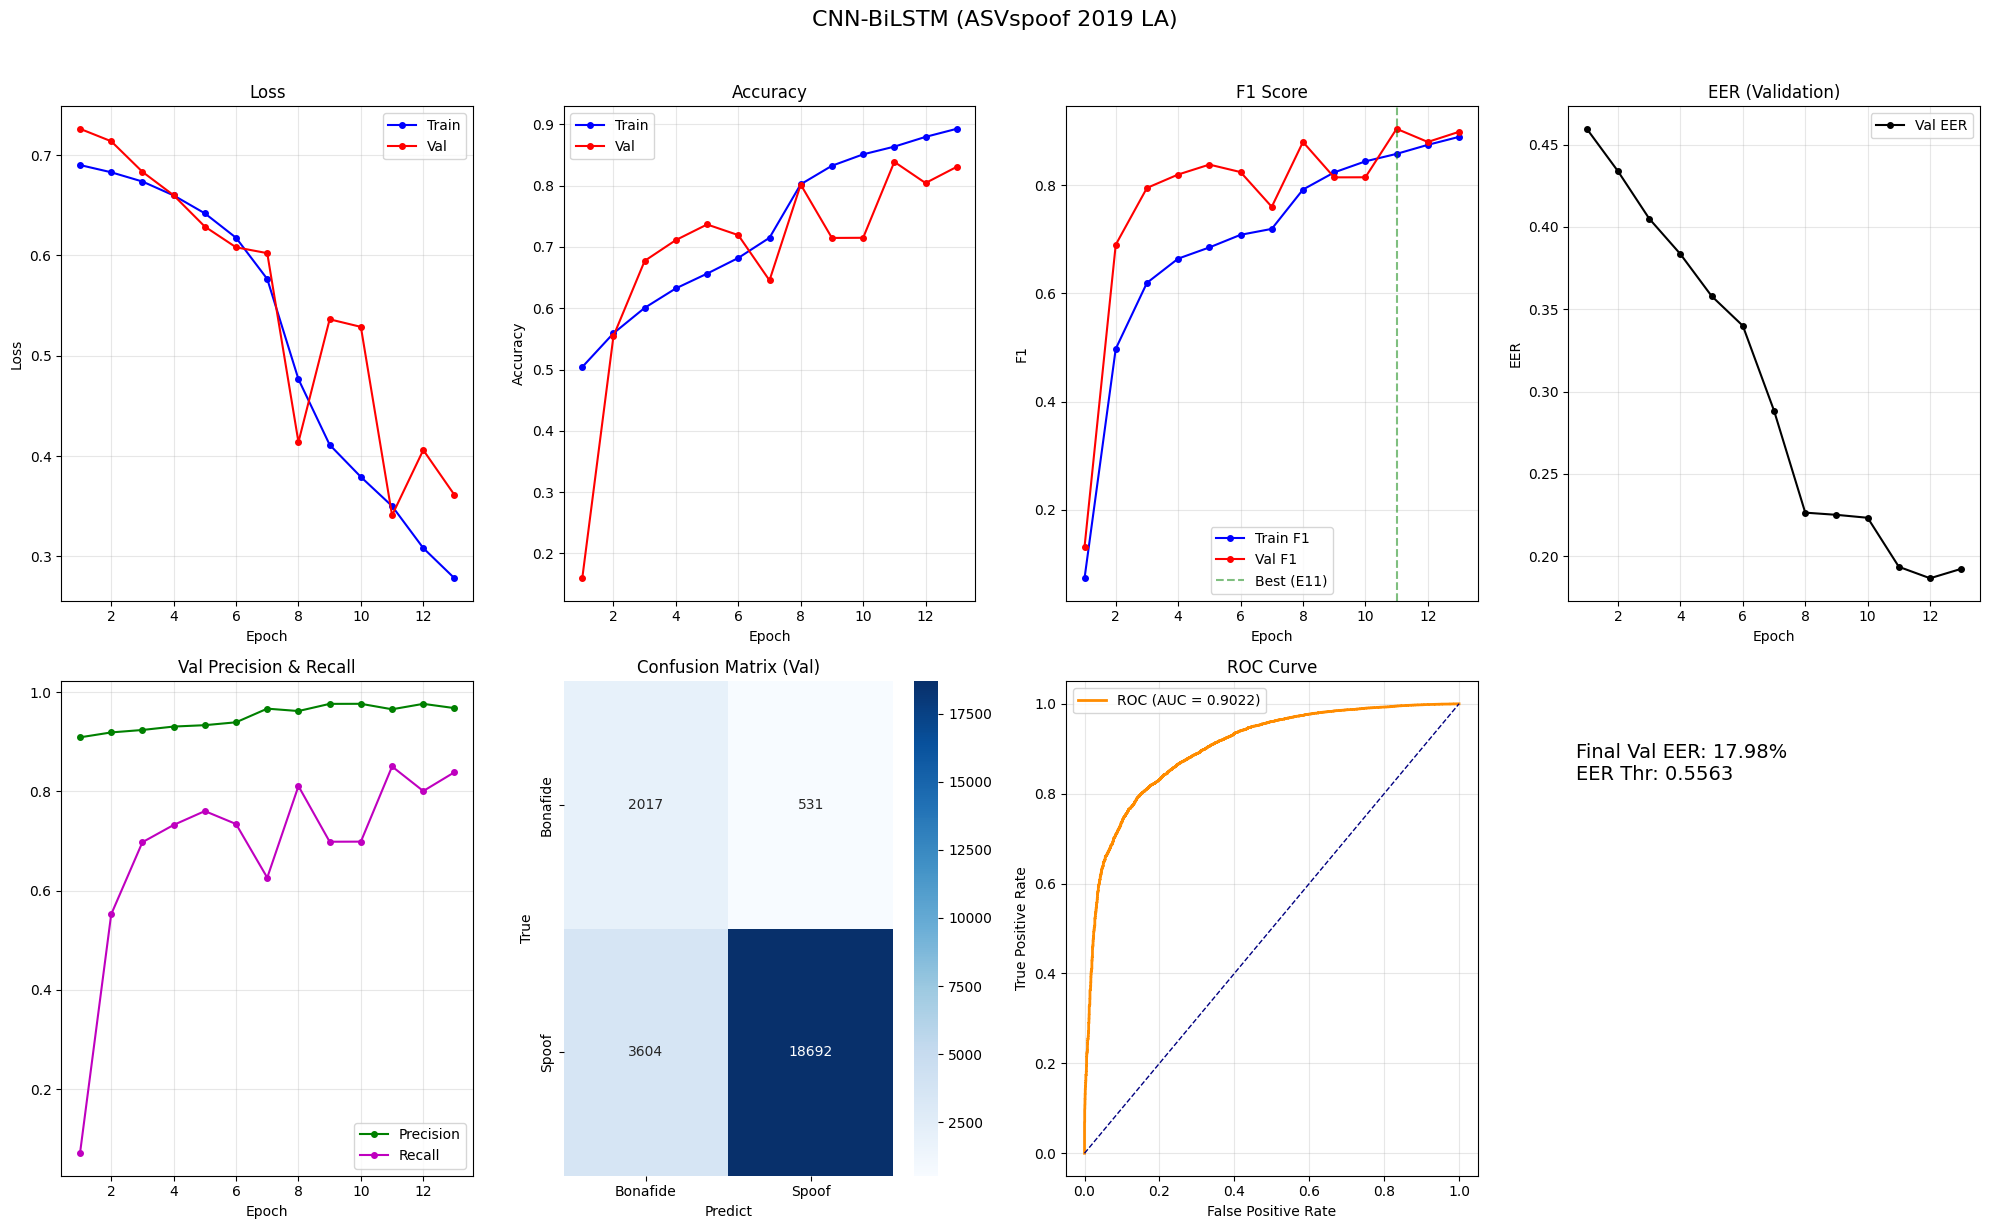


📋 详细分类报告 (验证集):
              precision    recall  f1-score   support

    Bonafide       0.36      0.79      0.49      2548
       Spoof       0.97      0.84      0.90     22296

    accuracy                           0.83     24844
   macro avg       0.67      0.81      0.70     24844
weighted avg       0.91      0.83      0.86     24844


📦 Step 8: 导出与原项目兼容的 deepvoice_config.json
✅ 配置文件已导出: /kaggle/working/model/deepvoice_config.json
✅ 训练元信息已导出: /kaggle/working/model/training_meta.json

📁 输出文件清单

╔══════════════════════════════════════════════════════════════════════╗
║  🎯 训练完成! 请下载以下文件到本地项目:                              ║
║                                                                      ║
║  1. model/best_f1_model.pt                                           ║
║     → deepvoice_detection/model/best_f1_model.pt                     ║
║                                                                      ║
║  2. model/deepvoice_config.json                                      ║


In [7]:
# ===================== Cell 10: 训练结果可视化 =====================
print("\n" + "=" * 70)
print("📉 Step 7: 训练结果可视化")
print("=" * 70)

fig, axes = plt.subplots(2, 4, figsize=(20, 12))
epochs_range = range(1, len(training_logs) + 1)

# Loss
axes[0, 0].plot(epochs_range, [l["Train Loss"] for l in training_logs], "b-o", label="Train", markersize=4)
axes[0, 0].plot(epochs_range, [l["Val Loss"] for l in training_logs], "r-o", label="Val", markersize=4)
axes[0, 0].set_title("Loss"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")

# Accuracy
axes[0, 1].plot(epochs_range, [l["Train Acc"] for l in training_logs], "b-o", label="Train", markersize=4)
axes[0, 1].plot(epochs_range, [l["Val Acc"] for l in training_logs], "r-o", label="Val", markersize=4)
axes[0, 1].set_title("Accuracy"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")

# F1 Score
axes[0, 2].plot(epochs_range, [l["Train F1"] for l in training_logs], "b-o", label="Train F1", markersize=4)
axes[0, 2].plot(epochs_range, [l["Val F1"] for l in training_logs], "r-o", label="Val F1", markersize=4)
axes[0, 2].axvline(x=best_epoch, color="green", linestyle="--", alpha=0.5, label=f"Best (E{best_epoch})")
axes[0, 2].set_title("F1 Score"); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("F1")

# EER
axes[0, 3].plot(epochs_range, [l["Val EER"] for l in training_logs], "k-o", label="Val EER", markersize=4)
axes[0, 3].set_title("EER (Validation)"); axes[0, 3].legend(); axes[0, 3].grid(True, alpha=0.3)
axes[0, 3].set_xlabel("Epoch"); axes[0, 3].set_ylabel("EER")

# Precision & Recall
axes[1, 0].plot(epochs_range, [l["Val Precision"] for l in training_logs], "g-o", label="Precision", markersize=4)
axes[1, 0].plot(epochs_range, [l["Val Recall"] for l in training_logs], "m-o", label="Recall", markersize=4)
axes[1, 0].set_title("Val Precision & Recall"); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlabel("Epoch")

# 最终验证集混淆矩阵
final_val = evaluate_model(model, val_dataloader, criterion)
cm = confusion_matrix(final_val["all_targets"], final_val["all_preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1],
            xticklabels=["Bonafide", "Spoof"], yticklabels=["Bonafide", "Spoof"])
axes[1, 1].set_title("Confusion Matrix (Val)"); axes[1, 1].set_ylabel("True"); axes[1, 1].set_xlabel("Predict")

# ROC 曲线
if final_val["all_probs"]:
    fpr, tpr, _ = roc_curve(final_val["all_targets"], final_val["all_probs"])
    roc_auc = auc(fpr, tpr)
    axes[1, 2].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1, 2].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    axes[1, 2].set_title("ROC Curve"); axes[1, 2].legend()
    axes[1, 2].set_xlabel("False Positive Rate"); axes[1, 2].set_ylabel("True Positive Rate")
    axes[1, 2].grid(True, alpha=0.3)

# 右下角：显示最终 EER 文本（也可以改成画阈值曲线）
axes[1, 3].axis("off")
axes[1, 3].text(
    0.02, 0.8,
    f"Final Val EER: {final_val['eer']*100:.2f}%\nEER Thr: {final_val['eer_threshold']:.4f}",
    fontsize=14
)

plt.suptitle("CNN-BiLSTM (ASVspoof 2019 LA)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/training_results.png", dpi=150, bbox_inches="tight")
plt.show()

# 详细分类报告
print("\n📋 详细分类报告 (验证集):")
print(classification_report(final_val["all_targets"], final_val["all_preds"],
                            target_names=["Bonafide", "Spoof"]))

# ===================== Cell 11: 导出兼容原项目的配置文件 =====================
print("\n" + "=" * 70)
print("📦 Step 8: 导出与原项目兼容的 deepvoice_config.json")
print("=" * 70)

# 生成与原项目 deepvoice_config.json 完全兼容的配置文件
# 这样本地的 predict_deepvoice.py 可以直接加载使用
export_config = {
    "data_paths": {
        "real_audio_dir": "deepvoice_detection/real_audio",
        "deepfake_audio_dir": "deepvoice_detection/deepfake_audio"
    },
    "feature_params": CONFIG["feature_params"],
    "model_params": CONFIG["model_params"],
    "training_params": {
        "num_epochs": training_config["num_epochs"],
        "batch_size": training_config["batch_size"],
        "learning_rate": training_config["learning_rate"],
        "num_workers": 0,
        "validation_split": 0.2,
        "random_seed": 42,
        "lr_scheduler_patience": training_config["lr_scheduler_patience"],
        "lr_scheduler_factor": training_config["lr_scheduler_factor"],
        "early_stopping_patience": training_config["early_stopping_patience"]
    },
    "output_paths": {
        "log_csv_path": "static/csv/train_deepfake_metrics_log.csv",
        "model_save_path": "deepvoice_detection/model/last_epoch_model.pt",
        "best_model_save_path": "deepvoice_detection/model/best_f1_model.pt"
    }
}

config_export_path = "/kaggle/working/model/deepvoice_config.json"
with open(config_export_path, "w", encoding="utf-8") as f:
    json.dump(export_config, f, indent=2, ensure_ascii=False)

# 保存训练元信息
meta_info = {
    "dataset": "ASVspoof 2019 LA",
    "train_samples": len(data["train_files"]),
    "val_samples": len(data["dev_files"]),
    "best_val_f1": best_val_f1,
    "best_epoch": best_epoch,
    "total_epochs_run": len(training_logs),
    "model_architecture": "AudioCNNLSTM (CNN-BiLSTM)",
    "feature": "MFCC-13",
}
with open("/kaggle/working/model/training_meta.json", "w") as f:
    json.dump(meta_info, f, indent=2)

print(f"✅ 配置文件已导出: {config_export_path}")
print(f"✅ 训练元信息已导出: /kaggle/working/model/training_meta.json")

# ===================== Cell 12: 文件清单与下载指引 =====================
print("\n" + "=" * 70)
print("📁 输出文件清单")
print("=" * 70)

# for item in Path("/kaggle/working").rglob("*"):
#     if item.is_file():
#         size_mb = item.stat().st_size / (1024 * 1024)
#         print(f"  {item.relative_to('/kaggle/working')} ({size_mb:.2f} MB)")

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║  🎯 训练完成! 请下载以下文件到本地项目:                              ║
║                                                                      ║
║  1. model/best_f1_model.pt                                           ║
║     → deepvoice_detection/model/best_f1_model.pt                     ║
║                                                                      ║
║  2. model/deepvoice_config.json                                      ║
║     → deepvoice_detection/deepvoice_config.json                      ║
║     (与原项目格式 100% 兼容, predict_deepvoice.py 可直接使用)         ║
║                                                                      ║
║  3. model/last_epoch_model.pt (备用)                                 ║
║     → deepvoice_detection/model/last_epoch_model.pt                  ║
║                                                                      ║
║  本地 predict_deepvoice.py 无需任何修改即可使用!                     ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("🏁 Notebook 运行完毕!")